In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle
import importlib
from scipy.stats import chisquare

import subcluster_funcs as funcs

importlib.reload(funcs)
sc._settings.settings._vector_friendly=True

import matplotlib
from statsmodels.stats.multitest import multipletests

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)
plots_dir = "plots_dir/"
os.makedirs(plots_dir, exist_ok=True)

In [3]:
cell_type = "Epicardial"

In [4]:
%%time
adata = sc.read_h5ad("../continuous_cov_corrected_no_scvi/" + cell_type  + ".h5ad")

CPU times: user 10.9 s, sys: 1.15 s, total: 12.1 s
Wall time: 20.7 s


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>

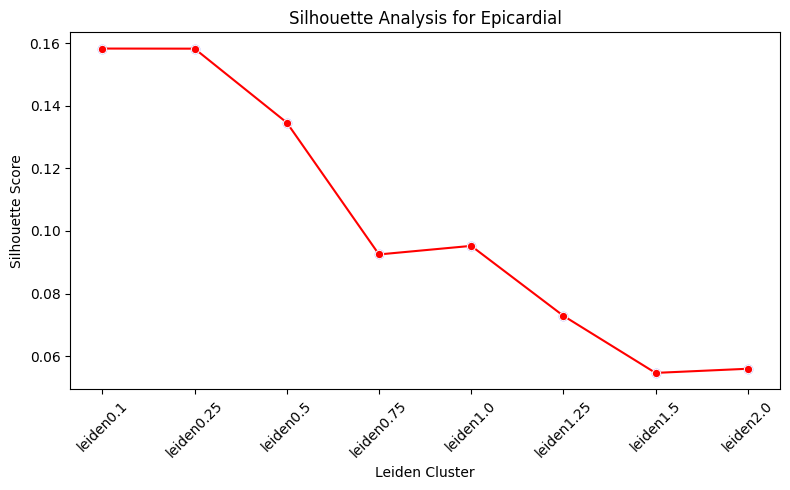

In [5]:
funcs.silhouette(adata, silhouette_res_dir = "../silhouette_res_scVI/", cell_type = cell_type)

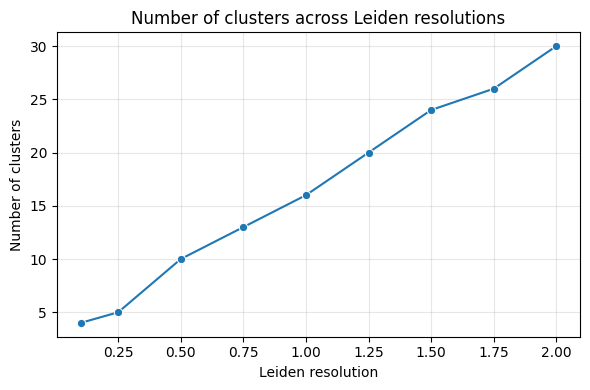

In [6]:
cluster_df, fig = funcs.leiden_resolution_summary(adata)

### Use Leiden 0.25

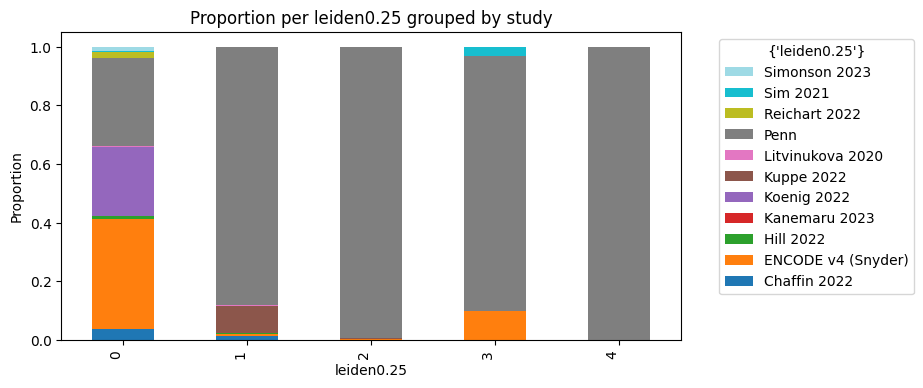

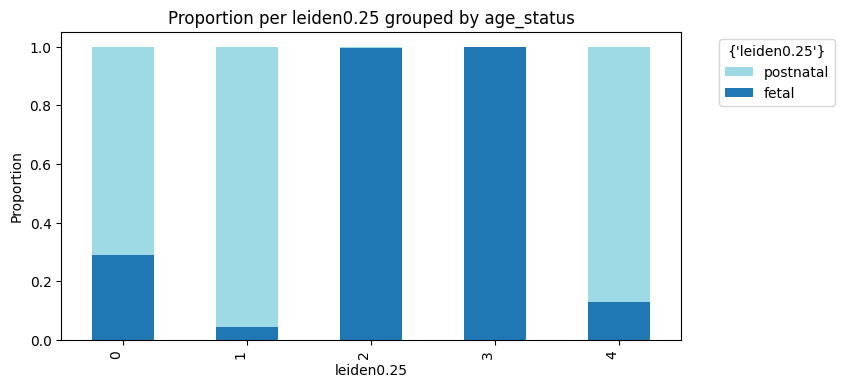

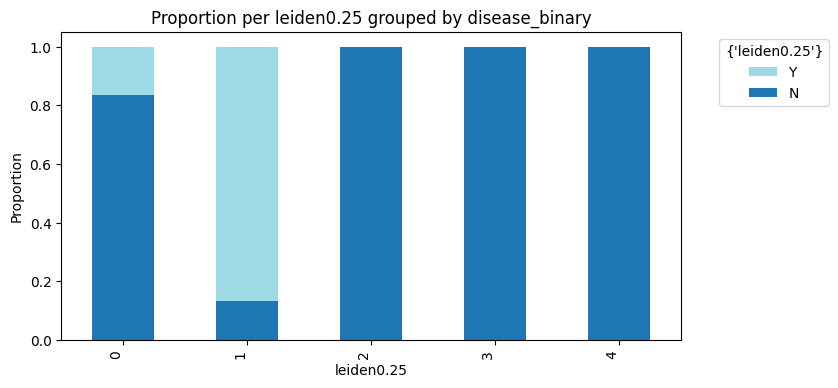

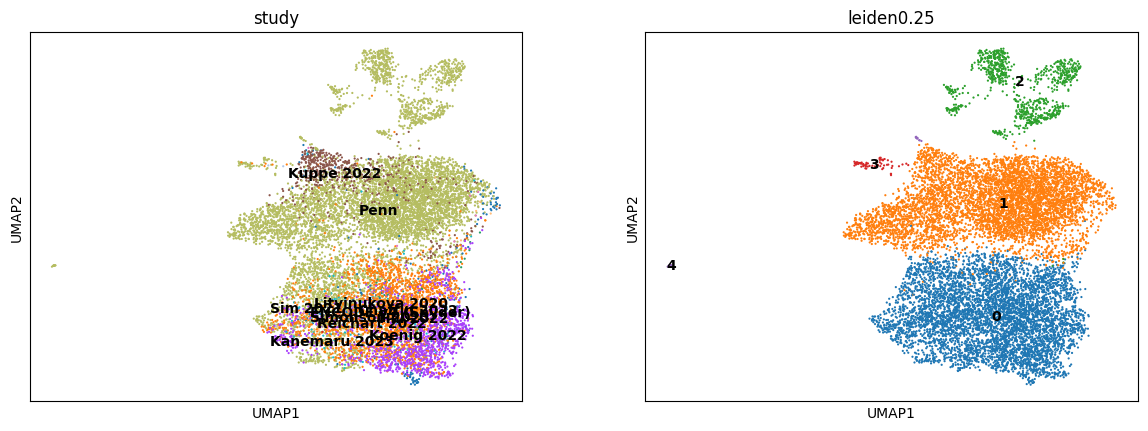

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean

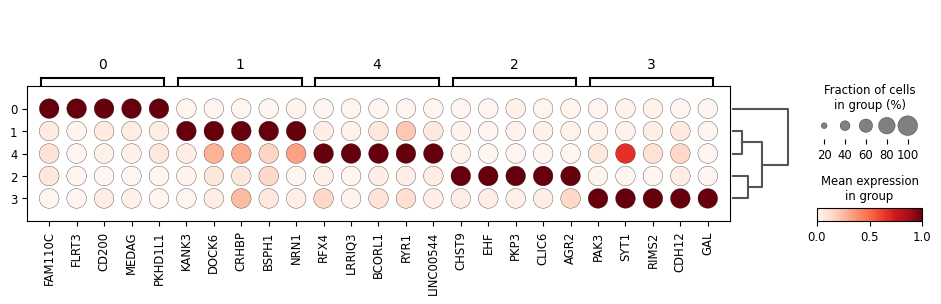

Counter({'1': 5555, '0': 5513, '2': 840, '3': 62, '4': 23})
CPU times: user 1min 1s, sys: 8min 52s, total: 9min 54s
Wall time: 40 s


['leiden0.25',
 AnnData object with n_obs × n_vars = 11993 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'total_UMI', 'log10_UMI', 'endo_score', 'cm_score', 'fib_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'l

In [7]:
%%time
leiden_key = "leiden0.25"
funcs.specify_leiden_subclustering(adata=adata, leiden=leiden_key)

Skipping Hill 2022: only 48 cells
Skipping Kanemaru 2023: only 2 cells
Skipping Litvinukova 2020: only 15 cells
Skipping Sim 2021: only 6 cells


/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/v2_aggregated_analysis/subclustering_analysis/perform_annotation/subcluster_funcs.py:233: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, idx in adata.obs.groupby(condition_key).indices.items():


Downsampling summary:
study
Penn                  7456
ENCODE v4 (Snyder)    2127
Koenig 2022           1305
Kuppe 2022             528
Chaffin 2022           276
Reichart 2022          132
Simonson 2023           98
Name: count, dtype: int64


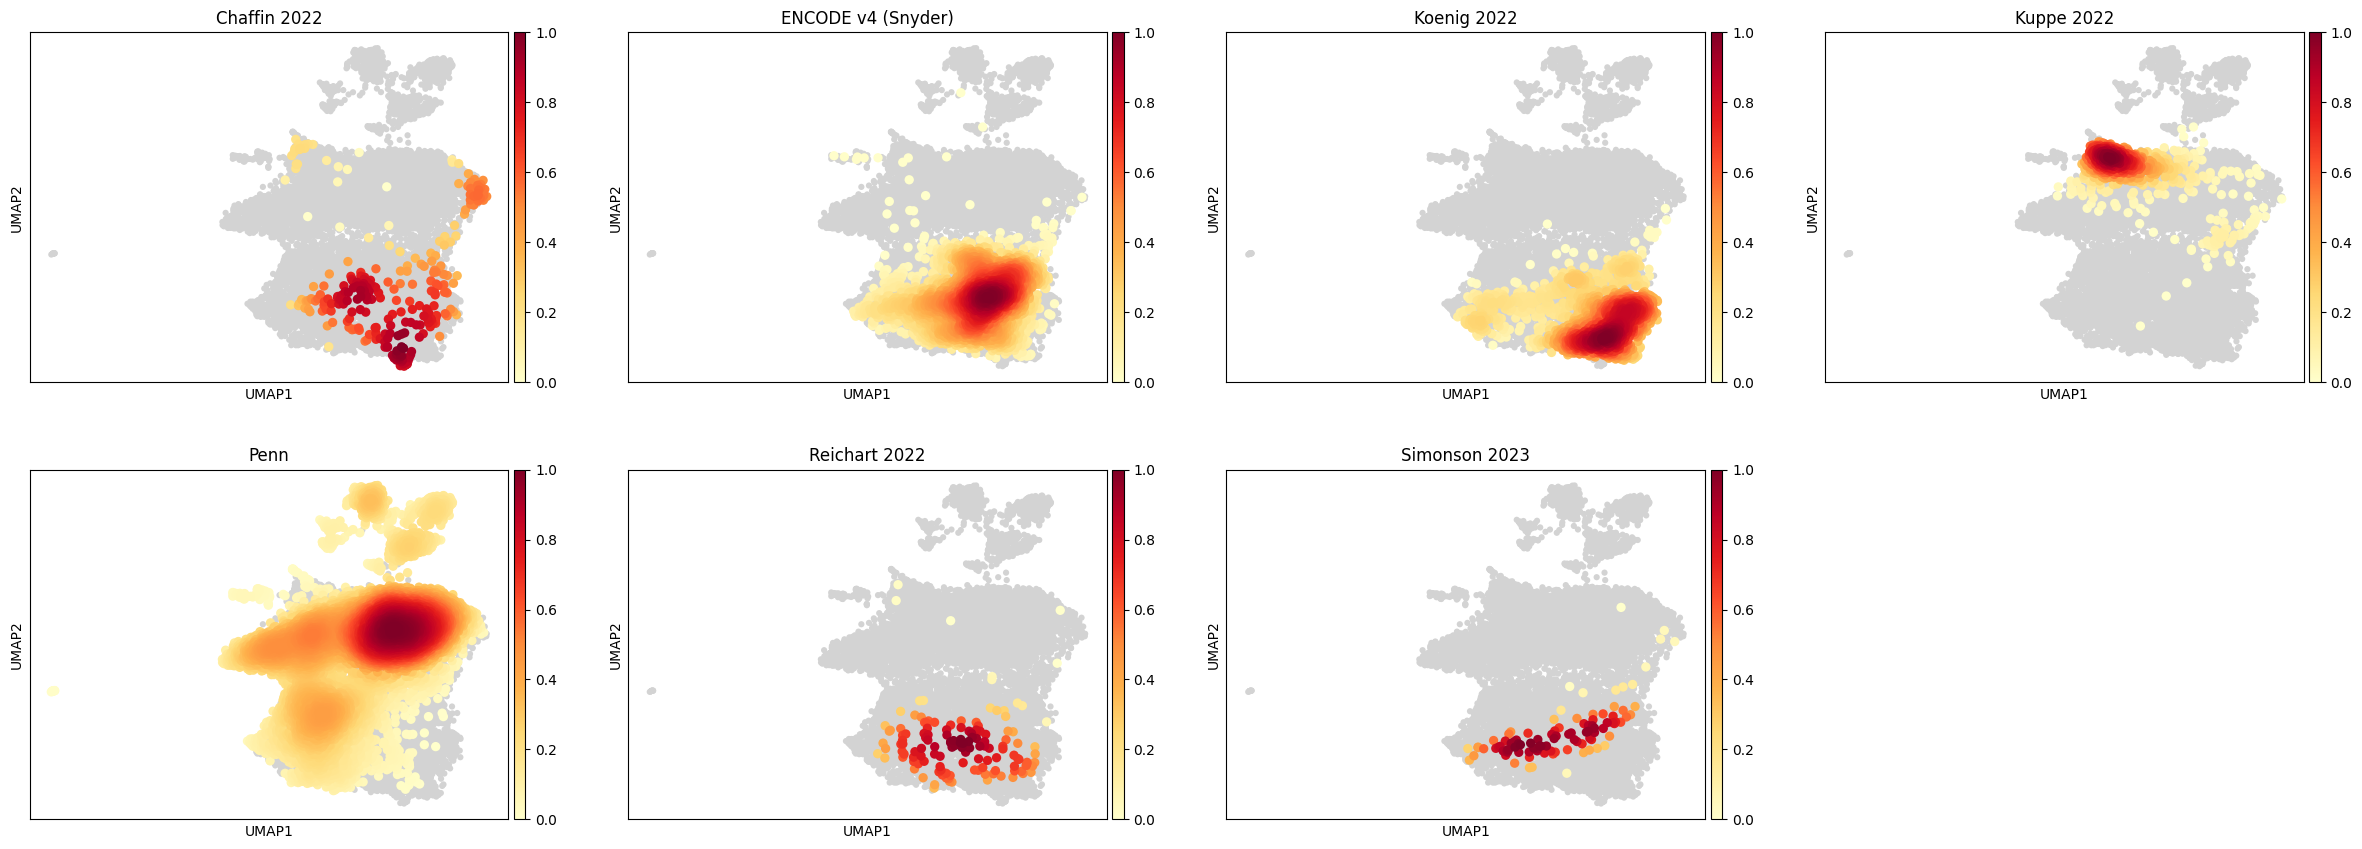

In [8]:
funcs.plot_umap_by_cluster(adata, condition_key = "study")

In [9]:
#sc.get.rank_genes_groups_df(adata, group="0").head(50)['names']

In [10]:
filt_adata = adata[adata.obs[leiden_key] != "4"]

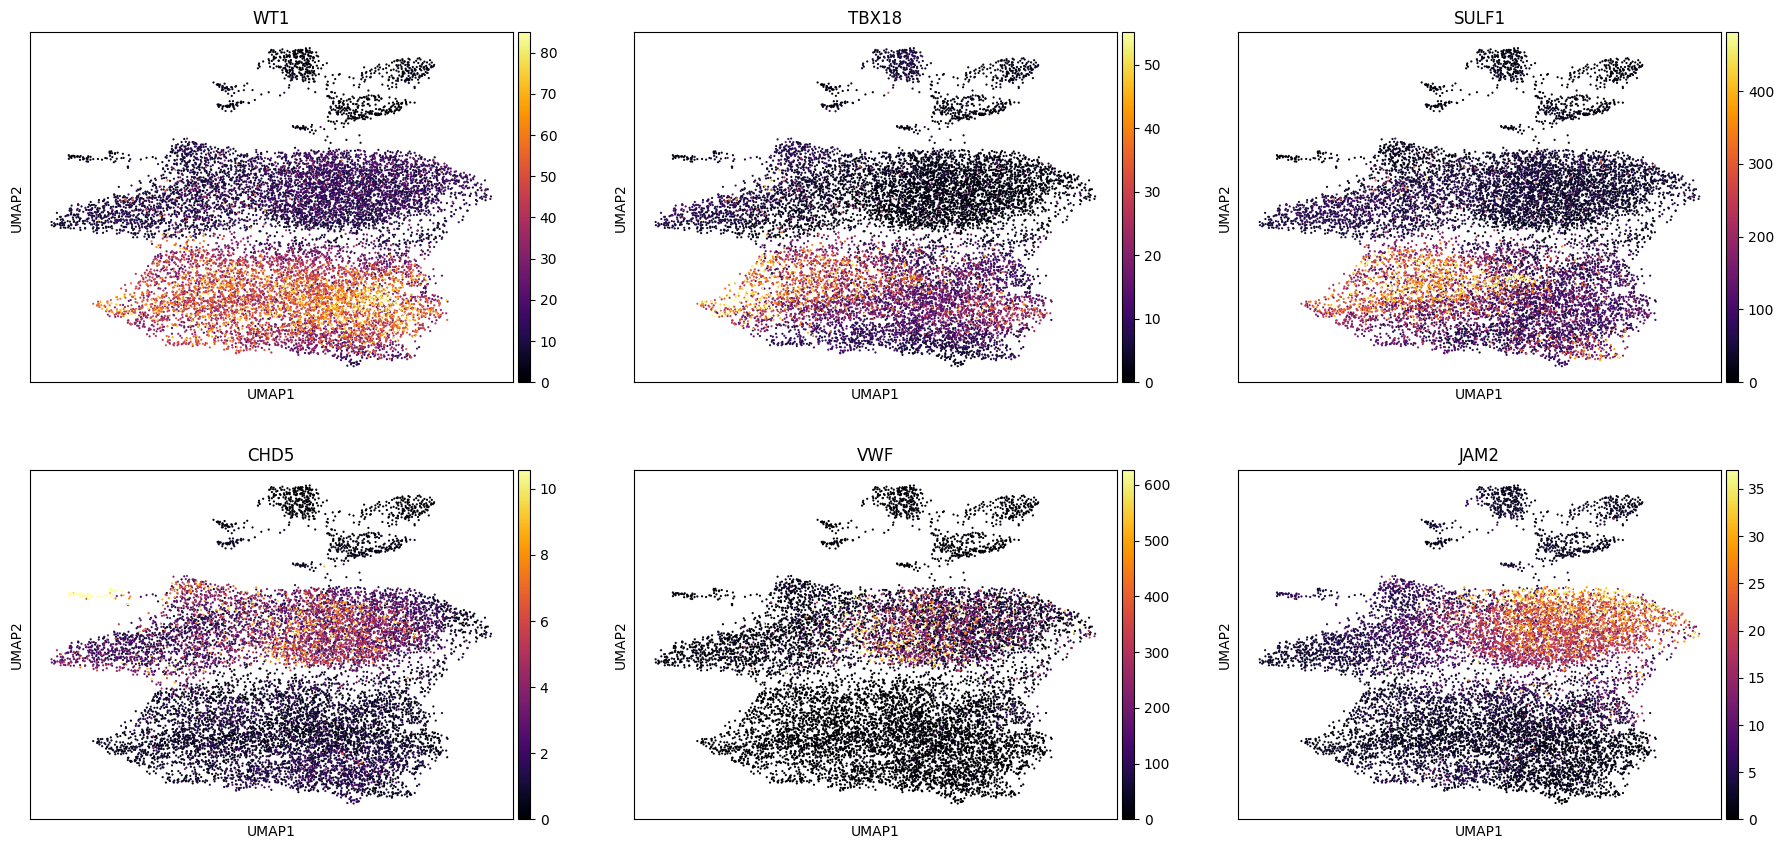

In [11]:
# epicardial markers are only in cluster 0
# other major cluster seems to express more endothelial-like markers (JAM)
with plt.rc_context():
    sc.pl.umap(filt_adata, color = ["WT1", "TBX18", "SULF1",
                          "CHD5", "VWF", "JAM2"], ncols=3, cmap="inferno", vmin=0, vmax="p99", show=False)
    plt.savefig(plots_dir + cell_type + "_feature_plots.pdf")

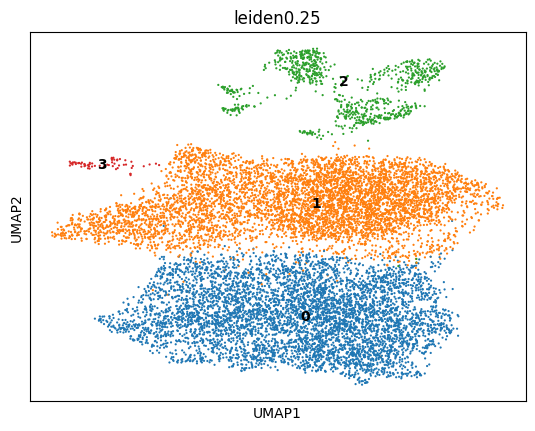

In [12]:
with plt.rc_context():
    sc.pl.umap(filt_adata, color = leiden_key, legend_loc = "on data", show=False)
    plt.savefig(plots_dir + cell_type + "_UMAP_before_filtering.pdf")

In [31]:
#sc.get.rank_genes_groups_df(adata, group="2")['names'].head(40)

#### Remove all clusters except cluster 0, which is the only cluster expressing strong Epicardial markers (WBT1/TCF21/SULF1)

In [13]:
Counter(adata.obs[leiden_key])

Counter({'1': 5555, '0': 5513, '2': 840, '3': 62, '4': 23})

In [14]:
filt_adata = adata[adata.obs[leiden_key] == "0"].copy()

In [15]:
filt_adata.obs['subcluster'] = "Epicardial"
palette = ["#BDBDBD"] 

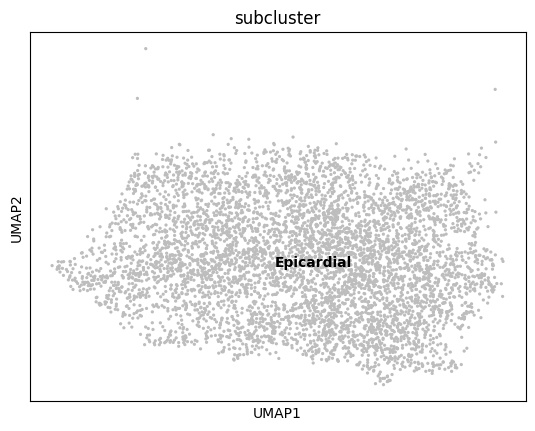

In [16]:
with plt.rc_context(): 
    sc.pl.umap(filt_adata, color = ['subcluster'], legend_loc = "on data", palette=palette, show=False)
    plt.savefig(plots_dir + cell_type + "_subclustered.pdf", bbox_inches="tight")

### Single cluster, do not proceed with subclustering or age-disease/aging analysis

In [17]:
filt_adata.obs.to_csv(post_subclustering_dir + cell_type + "_annotation.csv")

In [18]:
filt_adata.write(post_subclustering_dir + cell_type + ".h5ad")